# 02 · Firmware: da fonte à execução no processador

O firmware oficial da competição ainda não foi disponibilizado
(`docs/governance/SPEC_GAPS.md`, SG-05). Para provar a cadeia completa com
ferramentas reais, este firmware autoral em estilo `riscv-tests` testa 9 grupos
de instruções e grava uma assinatura na memória: `0x600DC0DE` se tudo passou,
`0xBAD00BAD` + número do teste se algo falhou.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # notebooks/_common.py
from _common import ROOT, run, py, summary, style, SERIES
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, Markdown, display
print("projeto:", ROOT.name)

projeto: ChampionCHIP (Terminar)


In [2]:
print((ROOT / "firmware/smoke/smoke_test.S").read_text(encoding="utf-8")[:2600])

/* =============================================================================
 * smoke_test.S - Firmware de smoke-test bare-metal (autoral - firmware
 * oficial da competicao indisponivel, ver SPEC_GAPS.md SG-05).
 *
 * Estilo "riscv-tests": cada bloco calcula um resultado com uma instrucao
 * real e compara com o valor esperado (bne ... fail). Se todos os blocos
 * passarem, grava a assinatura PASS_SIG em RESULT_ADDR e executa EBREAK.
 * Qualquer falha grava FAIL_SIG (+ numero do teste em a1) e para.
 *
 * Cobertura: ADD/SUB, OR/AND/XOR, shifts, SLT/SLTU, LUI/AUIPC, load/store
 * (word/byte, sign/zero extend), branch, JAL/JALR, MUL/MULH (Zmmul).
 * Nao repete a cobertura exaustiva ja feita em tb/isa/* - aqui o objetivo e
 * provar a cadeia toolchain -> ELF -> hex -> simulacao -> execucao real.
 * ============================================================================= */

.section .text.start
.globl _start
_start:
    li   sp, 0x10011ff0
    li   s0, 0            /* numero do 

## Compilação (GCC RISC-V, `-march=rv32im`, sem instruções comprimidas) e simulação

In [3]:
run("bash scripts/run_firmware_sim.sh", tail=6)

VCD info: dumpfile docs/evidence/waveforms/firmware_smoke.vcd opened for output.
[INFO] result_sig=600dc0de testnum=9 pc_final=0040018c
[ pass ] firmware smoke-test PASS (9 blocos)
=== tb_firmware_smoke: PASS ===
tb/firmware/tb_firmware_smoke.sv:70: $finish called at 3510 (1s)
[exit code 0]


0

In [4]:
dis = (ROOT / "firmware/build/smoke_test.dis").read_text(encoding="utf-8").splitlines()
print("\n".join(dis[:40]))


smoke_test.elf:     file format elf32-littleriscv


Disassembly of section .text:

00400000 <_start>:
  400000:	10012137          	lui	sp,0x10012
  400004:	ff010113          	addi	sp,sp,-16 # 10011ff0 <result_addr+0x1fd0>
  400008:	00000413          	li	s0,0

0040000c <test1_add_sub>:
  40000c:	00140413          	addi	s0,s0,1
  400010:	00c00293          	li	t0,12
  400014:	00500313          	li	t1,5
  400018:	006283b3          	add	t2,t0,t1
  40001c:	01100e13          	li	t3,17
  400020:	13c39c63          	bne	t2,t3,400158 <fail>
  400024:	406283b3          	sub	t2,t0,t1
  400028:	00700e13          	li	t3,7
  40002c:	13c39663          	bne	t2,t3,400158 <fail>

00400030 <test2_logic>:
  400030:	00140413          	addi	s0,s0,1
  400034:	0f000293          	li	t0,240
  400038:	00f00313          	li	t1,15
  40003c:	0062e3b3          	or	t2,t0,t1
  400040:	0ff00e13          	li	t3,255
  400044:	11c39a63          	bne	t2,t3,400158 <fail>
  400048:	0062f3b3          	and	t2,t0,t1
  40004c:	10

## Waveforms

Início: cada instrução passa por **FETCH → DECODE → EXECUTE → WRITE-BACK**
(4 ciclos para ALU; loads usam também MEM_READ e MEM_WAIT, porque a DMEM é síncrona).
Fim: a assinatura `0x600DC0DE` é montada, gravada na DMEM e o EBREAK levanta `halt_o`.

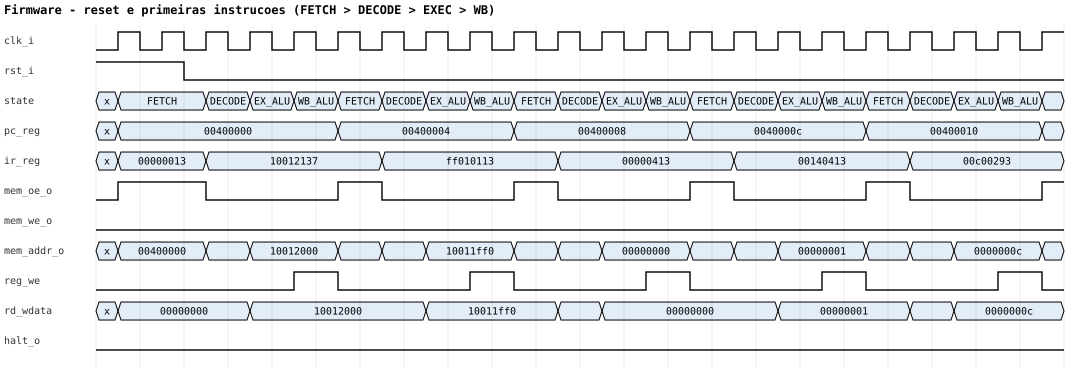

In [5]:
display(SVG(filename=str(ROOT / "docs/evidence/waveforms/firmware_inicio.svg")))

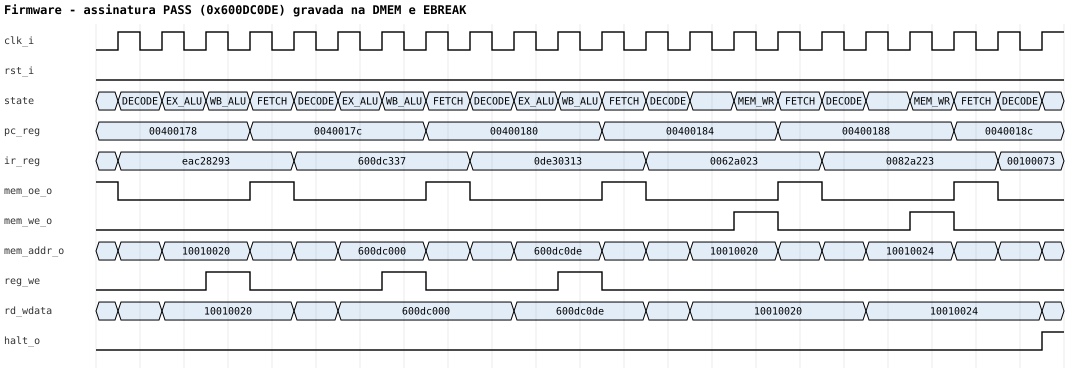

In [6]:
display(SVG(filename=str(ROOT / "docs/evidence/waveforms/firmware_fim.svg")))